In [1]:

import os
os.environ['MEMORY_LIMIT'] = '24GB'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
from os.path import exists, join
from io import StringIO  
from datetime import timedelta
import math

ALGORITHMS = {
    'structural': 'Structural filter',
    'sed': 'SED',
    'lblint': 'Label Intersection',
    'bib': 'Binary branch',
    'sedstruct': 'SEDStruct',
}

datasets = [ds for ds in os.listdir('datasets') if os.path.isdir(join('datasets', ds))]


In [2]:
real_datasets = [ds for ds in datasets if 'fanout' not in ds and 'labels-' not in ds]
label_datasets = [ds for ds in datasets if 'labels-' in ds]
fanout_datasets = [ds for ds in datasets if 'fanout' in ds]

In [3]:
algorithm_order = ['Label Intersection', 'Structural filter', 'SED', 'SEDStruct']

def read_query_times(dataset: str) -> pd.DataFrame:
    data = []
    file_path = join('datasets', dataset, 'query_times.csv')
    if not exists(file_path):
        return pd.DataFrame()
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    current_algorithm = None
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # Check if this is an algorithm name (doesn't contain ':')
        if ':' not in line:
            current_algorithm = line
        # Check if this is a time line
        elif line.startswith('time:'):
            time_str = line.replace('time:', '').replace('ms', '').strip()
            try:
                filter_time = float(time_str)
                alg_name = ALGORITHMS.get(current_algorithm.lower(), None)
                if alg_name is not None:
                  data.append({
                      'algorithm': alg_name,
                      'filter_time_ms': filter_time
                  })
            except ValueError:
                pass
    
    
    
    if data:
        return pd.DataFrame(data)
    else:
        return pd.DataFrame()

/tmp/ipykernel_22942/2315539744.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):


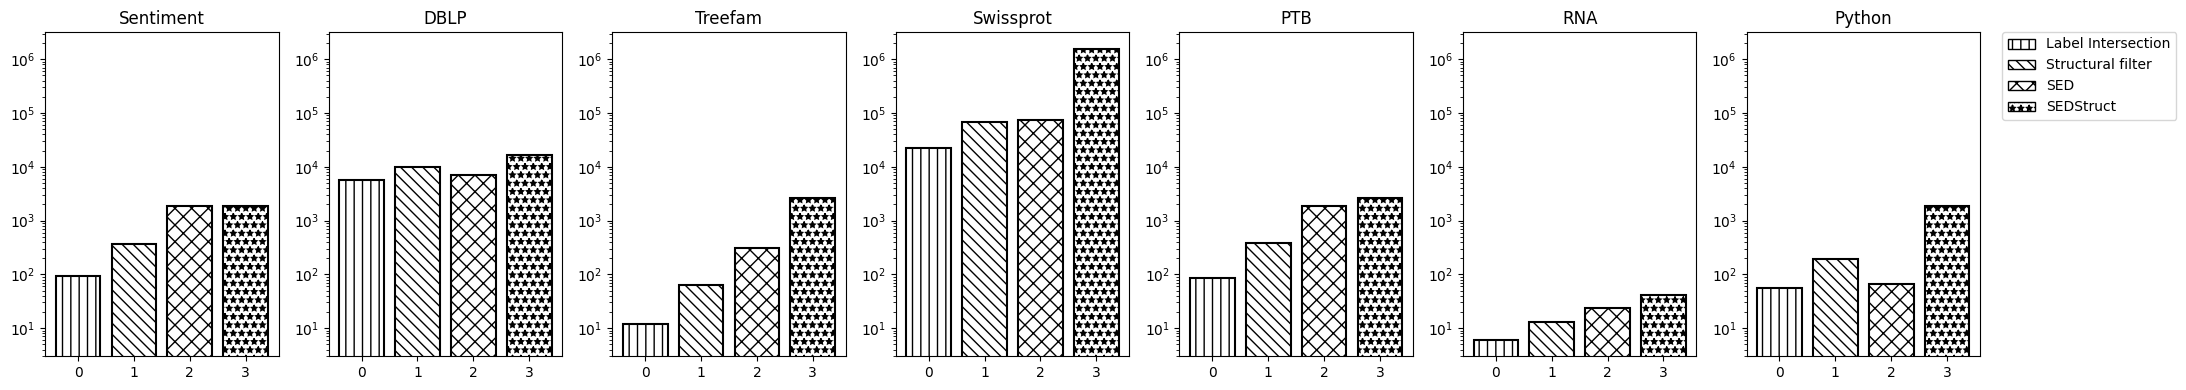

In [22]:
filter_df = pd.DataFrame()
for real_ds in real_datasets:
  filter_df_ds = read_query_times(real_ds)
  filter_df_ds['dataset'] = real_ds.capitalize() if real_ds not in ('dblp', 'rna', 'ptb') else real_ds.upper()
  filter_df = pd.concat([filter_df, filter_df_ds], ignore_index=True)
filter_df['algorithm'] = pd.Categorical(filter_df['algorithm'], categories=algorithm_order, ordered=True)
filter_df = filter_df.sort_values('algorithm')

hatch_patterns = {
    'Label Intersection': '||',
    'Structural filter': '\\\\\\',
    'SED': 'xx',
    'SEDStruct': '**'
}

# Calculate global min and max for normalization
global_min = filter_df['filter_time_ms'].min()
global_max = filter_df['filter_time_ms'].max()

fig, axes = plt.subplots(1, len(real_datasets), figsize=(20, 4))
for idx, dataset in enumerate(real_datasets):
  dataset_data = filter_df[filter_df['dataset'] == (dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper())]
  ax = axes[idx]
  
  for i, (algorithm, group) in enumerate(dataset_data.groupby('algorithm', sort=False)):
    bar = ax.bar(i, group['filter_time_ms'].values[0], color='white', edgecolor='black', linewidth=1.5, hatch=hatch_patterns[algorithm])
  
  ax.set_xticks(range(len(dataset_data['algorithm'].unique())))
  ax.set_yticks([])
  ax.set_title(dataset.capitalize() if dataset not in ('dblp', 'rna', 'ptb') else dataset.upper())
  ax.set_yscale('log')
  ax.set_ylim(global_min * 0.5, global_max * 2)

# Create legend for hatch patterns
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='black', hatch=hatch, label=alg) 
                   for alg, hatch in hatch_patterns.items()]
fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 0.925), ncol=1, frameon=True)

plt.tight_layout()
plt.show()